In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import LogisticRegression, LinearRegression
from matplotlib.colors import ListedColormap
import random

# np.random.seed(3498734)

In [20]:
def jitter(arr):
    return arr + np.random.randn(len(arr)) * .02

In [21]:
# 1. Load data, keep only patients with a known outcome (MCI patients)
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df["Progression to Alzheimer's Disease"].notna()].copy()

# 2. Fill missing numeric values with the column median
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)',
                 'CSF Phosphorylated tau (pg/mL)']
for col in numeric_cols:
    median_val = mci[col].median()
    mci[col] = mci[col].fillna(median_val)

# 3. Fill missing categorical values with the most common value
mode_val = mci['APOE4'].mode()[0]
mci['APOE4'] = mci['APOE4'].fillna(mode_val)

# 4. Convert categorical text columns to numeric (0/1)
mci['Sex'] = (mci['Sex'] == 'Male').astype(int)          # Male=1, Female=0
mci['APOE4'] = (mci['APOE4'] == 'Yes').astype(int)        # carries APOE4 allele=1, no=0
mci['Target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
df = mci.copy()
#df = df.rename(columns={'CSF Amyloid (pg/mL)': 'amyloid', 'CSF Phosphorylated tau (pg/mL)': 'tau', "Progression to Alzheimer's Disease" : 'progression'})
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)','CSF Phosphorylated tau (pg/mL)']
# 5. Final feature set + target
feature_cols = numeric_cols + ['Sex', 'APOE4']
X = df[feature_cols]
y = df['Target']

### Explore the data

In [27]:
X = model_df[['CSF Phosphorylated tau (pg/mL)']]
y = model_df['Target']

In [28]:
def sigmoid(beta0, beta1, x):
    return 1/(1 + np.exp(-beta0 - beta1*x))

<a  id="pairplot"></a>
## PairPlot

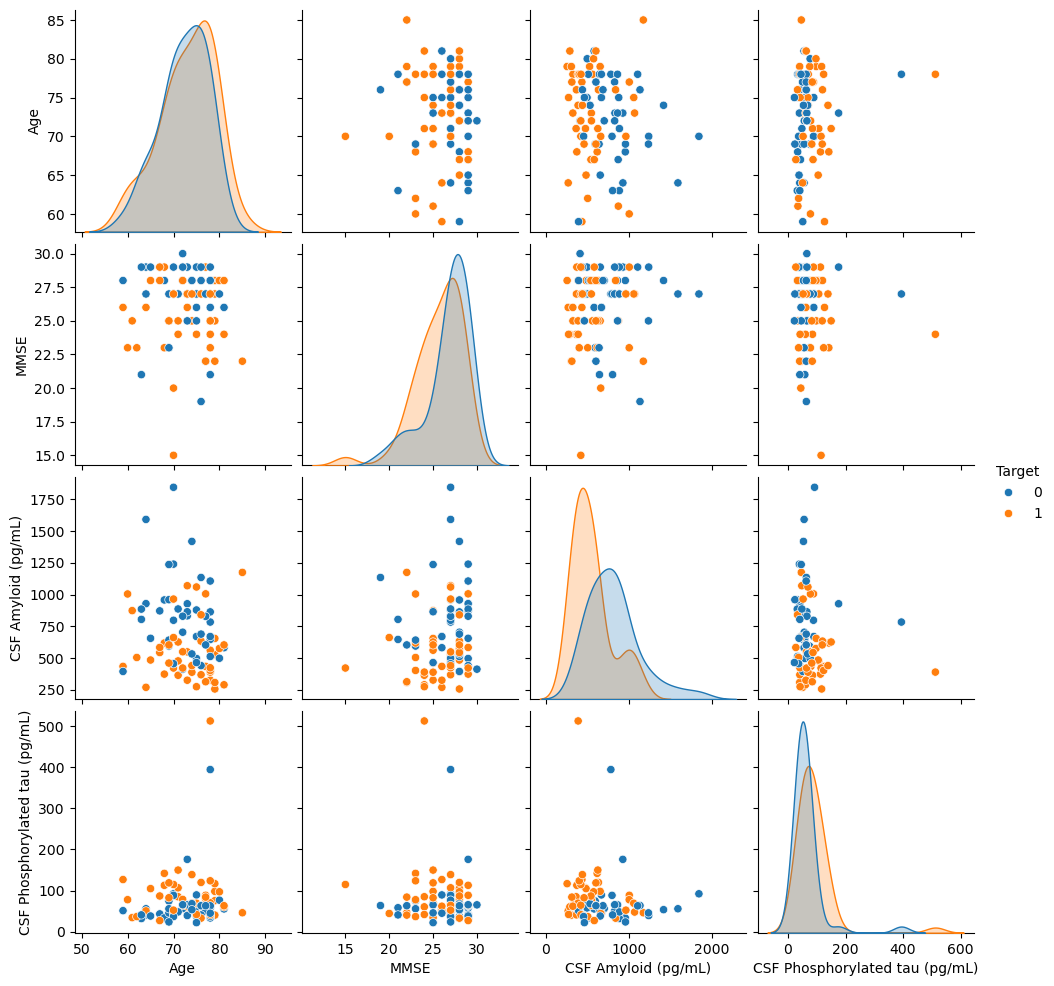

In [35]:
sns.pairplot(df[['Age','MMSE','CSF Amyloid (pg/mL)','CSF Phosphorylated tau (pg/mL)','Target']], hue='Target')
plt.savefig(f"images/pair_plot", dpi=300, bbox_inches="tight")

# PLOTTIG DECISION BOUNDARIES (FROM JOSH)
{a

/home/fazuskazoo/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


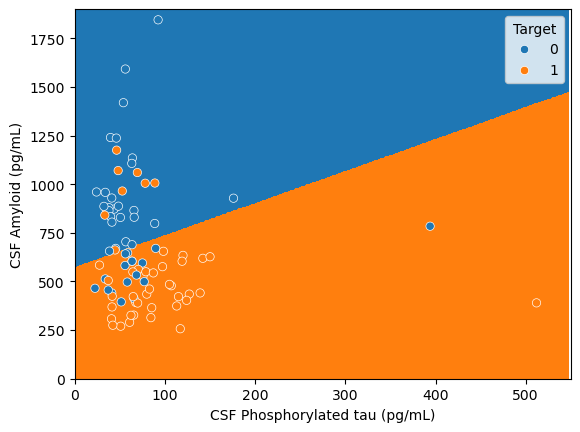

In [36]:
logistic_regression_model = LogisticRegression()
logistic_regression_model = logistic_regression_model.fit(df[['CSF Phosphorylated tau (pg/mL)', 'CSF Amyloid (pg/mL)']], df["Target"])


sns_cmap = ListedColormap(np.array(sns.color_palette())[0:2, :])

xx, yy = np.meshgrid(np.arange(0, 550, 2),
                     np.arange(0, 1900, 5))


Z_string = logistic_regression_model.predict(np.c_[xx.ravel(), yy.ravel()])
categories, Z_int = np.unique(Z_string, return_inverse=True)
Z_int = Z_int 
Z_int = Z_int.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z_int, cmap=sns_cmap)
sns.scatterplot(data = df, x = 'CSF Phosphorylated tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Target")
plt.xlim(0, 550);
plt.ylim(0, 1900);
plt.savefig(f"images/decision_boundary", dpi=300, bbox_inches="tight")

